# EDA - Alojamientos Turísticos (StaySpain)

**Equipo:** Equip_34;
**Fecha:** 07/07/2026;
**Dataset:** raw_dataset_06_07_2026.csv

Este notebook cubre únicamente el **EDA general** del dataset:
dimensiones, tipos de datos, nulos, duplicados, estadísticas
descriptivas, distribuciones, boxplots y correlaciones de las
principales variables.

Las preguntas de negocio específicas de cada perfil (marketing,
operaciones, experiencia del cliente) se desarrollan en notebooks
individuales.

Nota: los tratamientos aquí (parseo de fechas, columnas nuevas,
etc.) son solo para poder explorar los datos. La limpieza y
transformación "oficial" del dataset se documenta en las fases
correspondientes (Data Cleaning / Data Transformation) y no se
guarda desde este notebook.


## 1. Carga de datos e importación de librerías

In [24]:
# Librerías básicas para EDA
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo simple para los gráficos
sns.set_style("whitegrid")


In [ ]:
# Función para encontrar la carpeta raíz del proyecto

def encontrar_raiz_proyecto(nombre_carpeta='Equip_34'):
    """
    Busca la carpeta raíz del proyecto subiendo desde el
    directorio actual, hasta encontrar una carpeta con el
    nombre indicado.
    """
    actual = Path.cwd()
    for carpeta in [actual] + list(actual.parents):
        if carpeta.name == nombre_carpeta:
            return carpeta
    raise FileNotFoundError(
        f"No se encontró la carpeta '{nombre_carpeta}' "
        f"subiendo desde {actual}"
    )


raiz_proyecto = encontrar_raiz_proyecto('Equip_34')
ruta_csv = raiz_proyecto / 'Data' / 'raw_dataset_06_07_2026.csv'

print(f"Ruta resuelta: {ruta_csv}")

df = pd.read_csv(ruta_csv)
df.head()


Ruta resuelta: c:\Users\giorg\Desktop\ProjecteData\Equip_34\Data\raw_dataset_06_07_2026.csv


,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,NaN,Private room,2,2.0,1.0,...,100.0,100.0,100.0,100.0,100.0,FALSO,75.0,spain,malaga,31/07/2018
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,C�rmenes,Latina,Private room,1,1.0,1.0,...,90.0,100.0,100.0,80.0,90.0,FALSO,52.0,spain,madrid,10/01/2020
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1.0,2.0,...,100.0,100.0,100.0,100.0,100.0,VERDADERO,142.0,spain,sevilla,29/07/2019
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,l'Antiga Esquerra de l'Eixample,Eixample,Private room,2,2.0,1.0,...,90.0,100.0,100.0,100.0,90.0,VERDADERO,306.0,spain,barcelona,10/01/2020
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,NaN,Private room,5,1.0,2.0,...,100.0,100.0,100.0,100.0,100.0,FALSO,39.0,spain,girona,19/02/2019


## 2. Visión general del dataset

In [3]:
# Dimensiones del dataset: filas x columnas
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])


Filas: 8000
Columnas: 35


In [4]:
# Tipos de datos de cada columna
df.dtypes


apartment_id                     int64
name                            object
description                     object
host_id                          int64
neighbourhood_name              object
neighbourhood_district          object
room_type                       object
accommodates                     int64
bathrooms                      float64
bedrooms                       float64
beds                           float64
amenities_list                  object
price                          float64
minimum_nights                   int64
maximum_nights                   int64
has_availability                object
availability_30                  int64
availability_60                  int64
availability_90                  int64
availability_365                 int64
number_of_reviews                int64
first_review_date               object
last_review_date                object
review_scores_rating           float64
review_scores_accuracy         float64
review_scores_cleanliness

Recordatorio (Data Understanding): `first_review_date`,
`last_review_date` e `insert_date` llegan como texto en
formato dd/mm/yyyy. Para poder graficarlas como fechas las
convertimos aquí solo para el EDA, sin sobrescribir el csv
original.


In [5]:
# Convertimos las fechas de texto a formato fecha (solo para EDA)
df["first_review_date"] = pd.to_datetime(
    df["first_review_date"], format="%d/%m/%Y", errors="coerce"
)
df["last_review_date"] = pd.to_datetime(
    df["last_review_date"], format="%d/%m/%Y", errors="coerce"
)
df["insert_date"] = pd.to_datetime(
    df["insert_date"], format="%d/%m/%Y", errors="coerce"
)


In [6]:
# Rango temporal de insert_date (cuándo se registró cada anuncio)
print("Fecha más antigua:", df["insert_date"].min())
print("Fecha más reciente:", df["insert_date"].max())


Fecha más antigua: 2017-01-04 00:00:00
Fecha más reciente: 2021-02-27 00:00:00


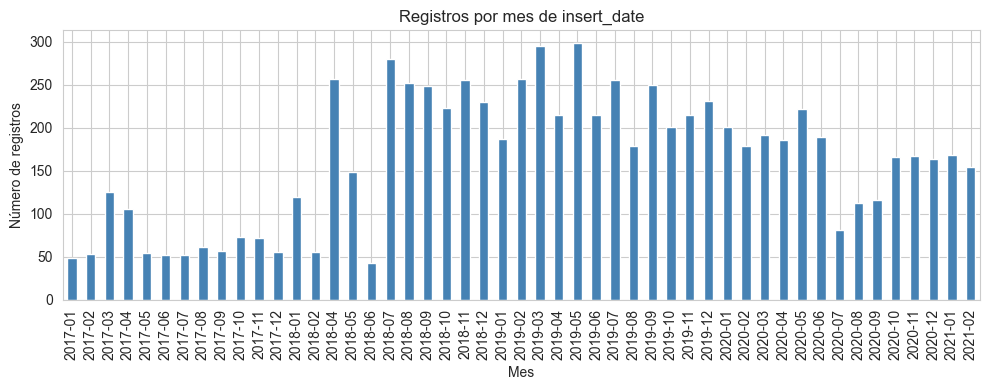

In [7]:
# Distribución temporal de insert_date (nº de registros por mes)
df["insert_date"].dt.to_period("M").value_counts().sort_index().plot(
    kind="bar", figsize=(10, 4), color="steelblue"
)
plt.title("Registros por mes de insert_date")
plt.xlabel("Mes")
plt.ylabel("Número de registros")
plt.tight_layout()
plt.show()


In [8]:
# Número de valores nulos por columna, ordenado de mayor a menor
nulos = df.isnull().sum().sort_values(ascending=False)
nulos[nulos > 0]


neighbourhood_district         3139
review_scores_value            1711
review_scores_location         1711
review_scores_checkin          1710
review_scores_accuracy         1705
review_scores_communication    1701
review_scores_cleanliness      1699
review_scores_rating           1696
last_review_date               1615
reviews_per_month              1614
first_review_date              1614
has_availability                550
price                           171
description                      54
bathrooms                        43
bedrooms                         39
amenities_list                   17
beds                              8
name                              3
dtype: int64

In [9]:
# Porcentaje de nulos sobre el total de filas
pct_nulos = (nulos[nulos > 0] / len(df) * 100).round(2)
pct_nulos


neighbourhood_district         39.24
review_scores_value            21.39
review_scores_location         21.39
review_scores_checkin          21.38
review_scores_accuracy         21.31
review_scores_communication    21.26
review_scores_cleanliness      21.24
review_scores_rating           21.20
last_review_date               20.19
reviews_per_month              20.18
first_review_date              20.18
has_availability                6.88
price                           2.14
description                     0.68
bathrooms                       0.54
bedrooms                        0.49
amenities_list                  0.21
beds                            0.10
name                            0.04
dtype: float64

`neighbourhood_district` sigue siendo el campo con más nulos
(alto porcentaje), y `has_availability` mantiene el bloque de
~550 nulos ya detectado en Data Understanding (pendiente de
revisión con IT).


In [10]:
# Duplicados: filas 100% idénticas
duplicados_totales = df.duplicated().sum()
print("Filas totalmente duplicadas:", duplicados_totales)

# Duplicados por apartment_id (mismo alojamiento, otra fila)
duplicados_id = df["apartment_id"].duplicated().sum()
print("apartment_id duplicados:", duplicados_id)


Filas totalmente duplicadas: 0
apartment_id duplicados: 307


Los `apartment_id` repetidos no son errores: corresponden a
**snapshots** del mismo alojamiento capturados en distintas
fechas (`insert_date` distinto para cada copia, ver ejemplo
abajo). Es decir, un mismo anuncio puede aparecer varias veces
porque el dataset se ha actualizado en varios momentos.

Para los análisis posteriores (incluidas las preguntas de
negocio en los notebooks individuales) se utilizará **el
registro más reciente de cada alojamiento** (último
`insert_date` por `apartment_id`), de forma que cada anuncio
cuente una sola vez.


In [11]:
# Ejemplo de snapshots del mismo alojamiento en distintas fechas
id_ejemplo = df["apartment_id"].value_counts().index[0]
columnas_ver = ["apartment_id", "insert_date", "price",
                "availability_365"]

df[df["apartment_id"] == id_ejemplo][columnas_ver]


,apartment_id,insert_date,price,availability_365
1910,10005342,2018-07-10,310.0,246
1911,10005342,2018-09-11,310.0,241
1912,10005342,2019-05-14,300.0,282


In [12]:
# Estadísticas descriptivas de las variables numéricas clave:
# precio, capacidad, disponibilidad y valoraciones
columnas_num = [
    "price", "accommodates", "bathrooms", "bedrooms", "beds",
    "minimum_nights", "maximum_nights", "number_of_reviews",
    "availability_30", "availability_60",
    "availability_90", "availability_365",
    "review_scores_rating", "review_scores_accuracy",
    "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location",
    "review_scores_value",
]
df[columnas_num].describe()


,price,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,number_of_reviews,availability_30,availability_60,availability_90,availability_365,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,7829.000000,8000.00000,7957.000000,7961.000000,7992.000000,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,6304.000000,6295.000000,6301.000000,6290.000000,6299.000000,6289.000000,6289.000000
mean,1007.751182,4.32700,1.598969,1.953147,2.971346,4.57125,761.230125,31.361750,12.391250,27.606750,44.599500,188.335875,919.698604,94.557585,93.162990,96.278219,96.353389,95.320401,91.408809
std,844.347373,2.59199,0.983736,1.290257,2.289586,11.80783,497.949602,57.083552,11.524301,22.408266,32.996787,129.643586,89.067148,9.241515,9.963916,8.038438,7.932885,7.507200,9.636507
min,60.000000,1.00000,0.000000,0.000000,0.000000,1.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,200.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
25%,450.000000,2.00000,1.000000,1.000000,1.000000,1.00000,62.000000,1.000000,0.000000,2.000000,9.000000,67.000000,890.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000
50%,750.000000,4.00000,1.000000,2.000000,2.000000,2.00000,1125.000000,8.000000,10.000000,27.000000,47.000000,190.000000,940.000000,100.000000,100.000000,100.000000,100.000000,100.000000,90.000000
75%,1220.000000,6.00000,2.000000,3.000000,4.000000,4.00000,1125.000000,36.000000,24.000000,50.000000,76.000000,316.000000,980.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
max,6071.000000,29.00000,12.000000,16.000000,30.000000,365.00000,1125.000000,588.000000,30.000000,60.000000,90.000000,365.000000,1000.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [25]:
# Estadísticas descriptivas de las variables categóricas
# (count, valores únicos, valor más frecuente y su frecuencia)
columnas_categoricas = [
    "city", "country", "room_type",
    "neighbourhood_district",
    "is_instant_bookable", "has_availability",
]

df[columnas_categoricas].describe()

,city,country,room_type,neighbourhood_district,is_instant_bookable,has_availability
count,8000,8000,8000,4861,8000,7450
unique,8,1,4,61,2,1
top,barcelona,spain,Entire home/apt,Centro,VERDADERO,VERDADERO
freq,2358,8000,5680,871,4439,7450


## 3. Distribuciones y boxplots de variables representativas

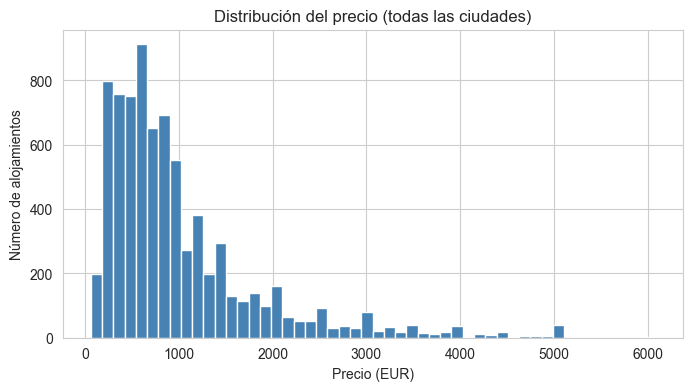

In [13]:
# Distribución del precio: histograma
# (price tiene nulos, se excluyen solo para este gráfico)
plt.figure(figsize=(8, 4))
plt.hist(df["price"].dropna(), bins=50, color="steelblue")
plt.title("Distribución del precio (todas las ciudades)")
plt.xlabel("Precio (EUR)")
plt.ylabel("Número de alojamientos")
plt.show()


El histograma muestra una fuerte asimetría a la derecha: la
mayoría de los precios se concentra en valores bajos/medios,
con una cola larga de alojamientos de precio muy alto (posibles
alojamientos de lujo o valores atípicos).


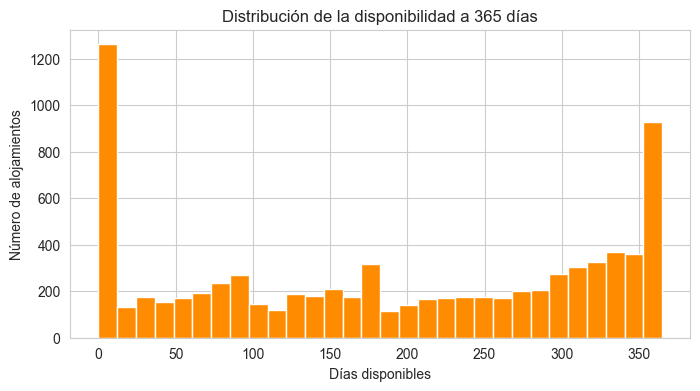

In [14]:
# Distribución de la disponibilidad a 365 días
plt.figure(figsize=(8, 4))
plt.hist(df["availability_365"].dropna(), bins=30, color="darkorange")
plt.title("Distribución de la disponibilidad a 365 días")
plt.xlabel("Días disponibles")
plt.ylabel("Número de alojamientos")
plt.show()


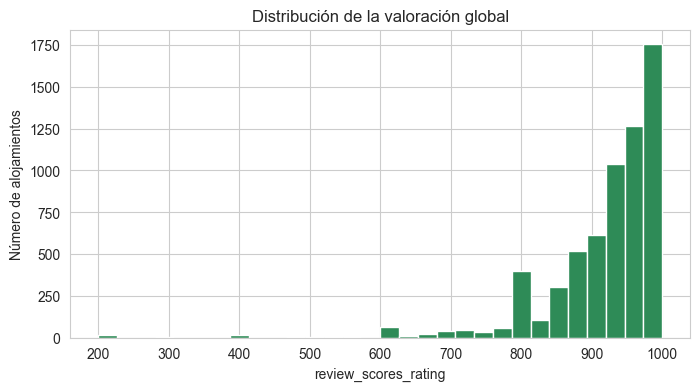

In [15]:
# Distribución de la valoración global (review_scores_rating)
plt.figure(figsize=(8, 4))
plt.hist(
    df["review_scores_rating"].dropna(), bins=30, color="seagreen"
)
plt.title("Distribución de la valoración global")
plt.xlabel("review_scores_rating")
plt.ylabel("Número de alojamientos")
plt.show()


La valoración global está muy concentrada en valores altos
(la mayoría de alojamientos recibe puntuaciones cercanas al
máximo), con una cola de valores bajos menos frecuentes.


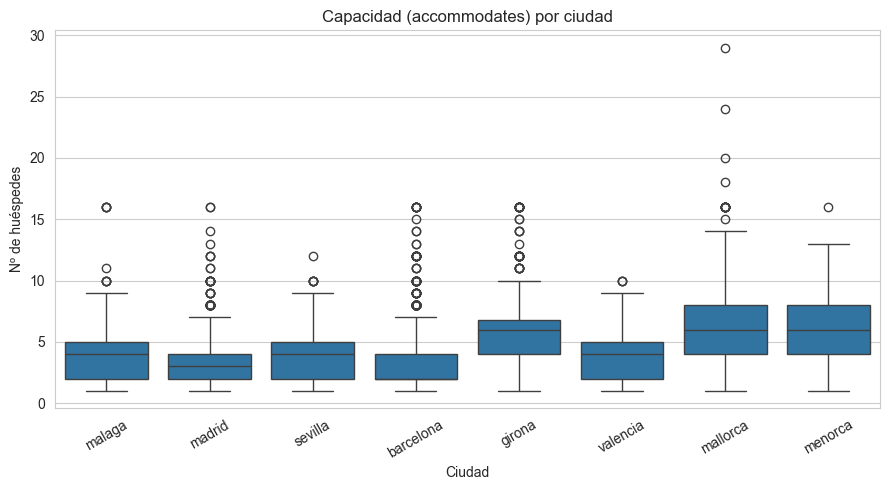

In [16]:
# Boxplot de accommodates por ciudad (capacidad)
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="city", y="accommodates")
plt.title("Capacidad (accommodates) por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Nº de huéspedes")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


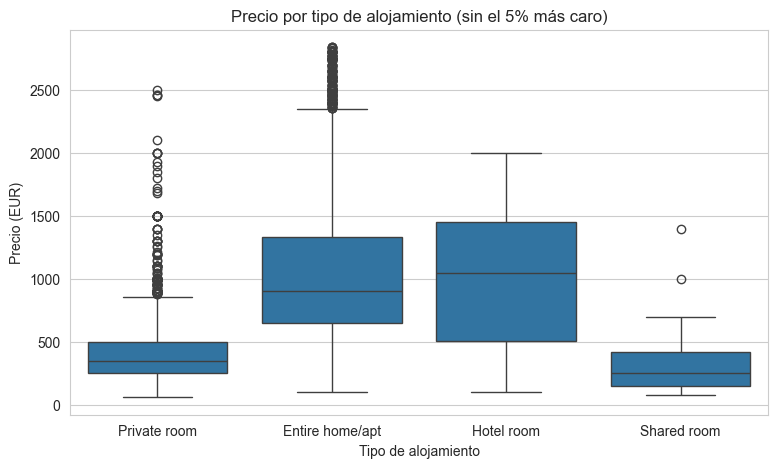

In [17]:
# Boxplot del precio por tipo de alojamiento
# (se excluye el 5% más caro solo para visualizar mejor)
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df[df["price"] < df["price"].quantile(0.95)],
    x="room_type", y="price",
)
plt.title("Precio por tipo de alojamiento (sin el 5% más caro)")
plt.xlabel("Tipo de alojamiento")
plt.ylabel("Precio (EUR)")
plt.show()


## 4. Matriz de correlación general

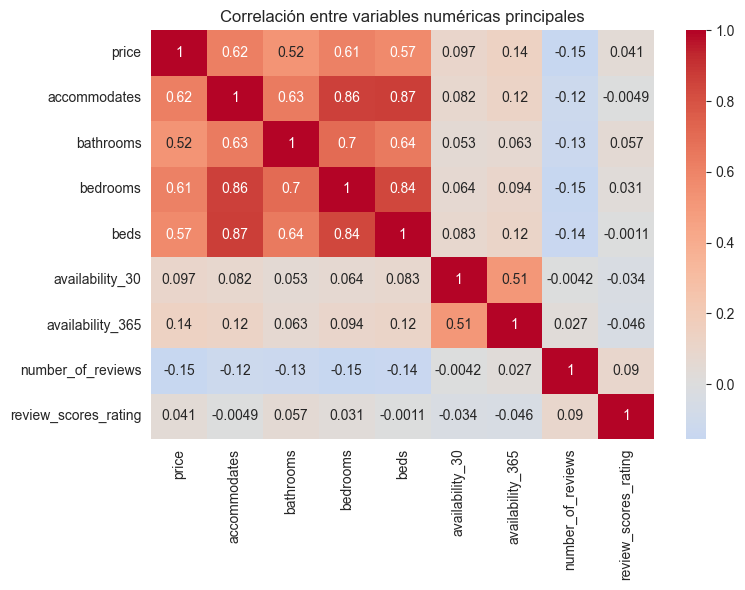

In [18]:
# Correlación entre las principales variables numéricas
columnas_correlacion = [
    "price", "accommodates", "bathrooms", "bedrooms", "beds",
    "availability_30", "availability_365",
    "number_of_reviews", "review_scores_rating",
]

matriz_corr = df[columnas_correlacion].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlación entre variables numéricas principales")
plt.tight_layout()
plt.show()


`accommodates`, `bedrooms` y `beds` muestran una correlación
moderada-alta con el precio. La disponibilidad y la valoración
global tienen, en general, una correlación baja con el resto de
variables numéricas, por lo que no muestran relaciones lineales
fuertes a nivel general (esto no descarta relaciones más
específicas, que se explorarán en los notebooks de cada
pregunta de negocio).


## 5. Variables categóricas

In [19]:
# Distribución de room_type
df["room_type"].value_counts()


room_type
Entire home/apt    5680
Private room       2215
Hotel room           54
Shared room          51
Name: count, dtype: int64

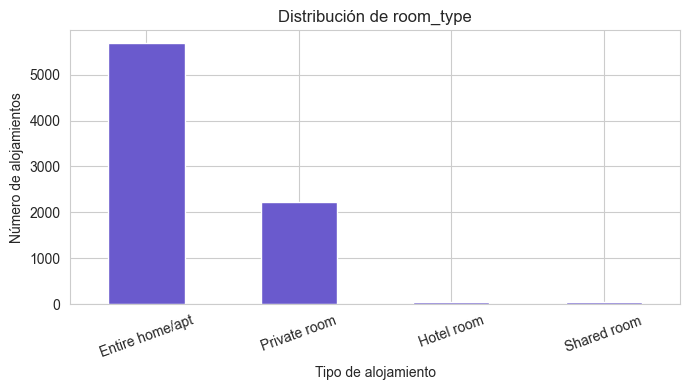

In [20]:
plt.figure(figsize=(7, 4))
df["room_type"].value_counts().plot(kind="bar", color="slateblue")
plt.title("Distribución de room_type")
plt.xlabel("Tipo de alojamiento")
plt.ylabel("Número de alojamientos")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [21]:
# Distribución de is_instant_bookable
df["is_instant_bookable"].value_counts()


is_instant_bookable
VERDADERO    4439
FALSO        3561
Name: count, dtype: int64

In [22]:
# Distribución de has_availability (incluye los nulos)
df["has_availability"].value_counts(dropna=False)


has_availability
VERDADERO    7450
NaN           550
Name: count, dtype: int64

`has_availability` solo tiene un valor posible (VERDADERO) y
un bloque de nulos (~550 registros): no hay ningún registro con
valor FALSO, lo cual sigue siendo la anomalía ya reportada a
IT en Data Understanding.


In [23]:
# Alojamientos por ciudad (para dimensionar cada mercado)
df["city"].value_counts()


city
barcelona    2358
madrid       1703
mallorca     1318
girona       1242
sevilla       428
malaga        408
valencia      372
menorca       171
Name: count, dtype: int64

## 6. Conclusiones y próximos pasos

- El dataset tiene una asimetría fuerte en precio y una
  concentración alta en las valoraciones, algo a tener en
  cuenta en cualquier análisis posterior.
- Los `apartment_id` duplicados son snapshots temporales, no
  errores; los análisis posteriores usarán el registro más
  reciente de cada alojamiento.
- Las correlaciones lineales generales son moderadas para
  precio-capacidad y bajas para disponibilidad/valoración; cada
  pregunta de negocio profundizará en su propio notebook.

